# NB06 — Accessory-Genome Enrichment (H1c)

**Purpose**: Test whether defense-system gene clusters are enriched in the
accessory pangenome (`is_auxiliary` and `is_singleton`) relative to the
background pangenome-wide fraction. Enrichment is consistent with mobile
defense-island transfer being the dominant transmission mode for defense
systems (Rocha & Bikard 2022).

**Approach**:
1. Compute per-system fraction of gene clusters that are core, auxiliary, or singleton.
2. Compute pangenome-wide background fractions from `pangenome` table (across all species).
3. χ² test per system: defense fraction vs background.
4. Bar plot of fractions by system.

**Output**: `data/accessory_enrichment.tsv`, `figures/core_vs_accessory_by_system.png`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from berdl_notebook_utils.setup_spark_session import get_spark_session

spark = get_spark_session()

DATA_DIR = "../data"
FIG_DIR = "../figures"

## 1. Load defense hits and dedupe to (cluster, system)

In [2]:
hits = pd.read_csv(os.path.join(DATA_DIR, "defense_gene_clusters.tsv.gz"), sep="\t")
print(f"Hits: {len(hits):,} rows")

# Dedupe: one row per gene cluster per system
cluster_sys = (
    hits.groupby(["gene_cluster_id", "system"], as_index=False)
    .agg(is_core=("is_core", "max"),
         is_auxiliary=("is_auxiliary", "max"),
         is_singleton=("is_singleton", "max"))
)
print(f"Deduped (cluster, system) rows: {len(cluster_sys):,}")

Hits: 930,573 rows


Deduped (cluster, system) rows: 834,917


## 2. Per-system core/auxiliary/singleton fractions

In [3]:
sys_summary = []
for sys in cluster_sys["system"].unique():
    sub = cluster_sys[cluster_sys["system"] == sys]
    n = len(sub)
    n_core = int(sub["is_core"].sum())
    n_aux = int(sub["is_auxiliary"].sum())
    n_sing = int(sub["is_singleton"].sum())
    sys_summary.append({
        "system": sys,
        "n_clusters": n,
        "n_core": n_core,
        "n_auxiliary": n_aux,
        "n_singleton": n_sing,
        "pct_core": 100.0 * n_core / n,
        "pct_auxiliary": 100.0 * n_aux / n,
        "pct_singleton": 100.0 * n_sing / n,
    })
sys_df = pd.DataFrame(sys_summary).sort_values("pct_core", ascending=False)
sys_df

,system,n_clusters,n_core,n_auxiliary,n_singleton,pct_core,pct_auxiliary,pct_singleton
4,DISARM,130149,52877,77272,55007,40.628049,59.371951,42.264635
3,CRISPR-Cas,213287,58386,154901,100718,27.374383,72.625617,47.221818
2,BREX,134013,27722,106291,74713,20.686053,79.313947,55.750562
7,CBASS,2996,353,2643,1830,11.782377,88.217623,61.081442
1,R-M Type I,243960,23953,220007,159289,9.818413,90.181587,65.293081
6,R-M Type II,27449,2590,24859,18708,9.435681,90.564319,68.155488
5,Gabija,12830,1172,11658,8824,9.134840,90.865160,68.776306
0,Retron,70233,5766,64467,46230,8.209816,91.790184,65.823758


## 3. Background pangenome-wide fractions

Sum core/aux/singleton across all species from `pangenome` table.

In [4]:
bg = spark.sql("""
    SELECT
        SUM(no_core) AS bg_core,
        SUM(no_aux_genome) AS bg_aux,
        SUM(no_singleton_gene_clusters) AS bg_sing,
        SUM(no_gene_clusters) AS bg_total
    FROM kbase_ke_pangenome.pangenome
""").toPandas().iloc[0]
bg_core = int(bg["bg_core"])
bg_aux = int(bg["bg_aux"])
bg_sing = int(bg["bg_sing"])
bg_total = int(bg["bg_total"])
print(f"Background: core={bg_core:,}  aux={bg_aux:,}  singleton={bg_sing:,}  total={bg_total:,}")
print(f"  pct_core={100*bg_core/bg_total:.2f}%  pct_aux={100*bg_aux/bg_total:.2f}%  pct_sing={100*bg_sing/bg_total:.2f}%")

# NOTE: pangenome's is_singleton is a SUBSET of is_auxiliary. is_core+is_aux = total
# (verified in pitfalls.md).

Background: core=62,062,686  aux=70,468,815  singleton=50,203,195  total=132,531,501
  pct_core=46.83%  pct_aux=53.17%  pct_sing=37.88%


## 4. χ² test per system: defense core/aux/singleton vs background

2×3 contingency: [core, non-singleton auxiliary, singleton] vs
background [core, non-singleton auxiliary, singleton].

In [5]:
# Background non-singleton auxiliary = bg_aux - bg_sing
bg_aux_ns = bg_aux - bg_sing
bg_row = [bg_core, bg_aux_ns, bg_sing]

chi_results = []
for sys in sys_df["system"]:
    row = sys_df[sys_df["system"] == sys].iloc[0]
    d_core = int(row["n_core"])
    d_sing = int(row["n_singleton"])
    # d_aux from summary counts EVERY auxiliary (singleton and non-singleton).
    # For a non-overlapping 3-way contingency: non-singleton auxiliary = aux - singleton.
    d_aux_ns = int(row["n_auxiliary"]) - d_sing
    d_row = [d_core, d_aux_ns, d_sing]
    tbl = [d_row, bg_row]
    chi2, p, _, _ = chi2_contingency(tbl)
    chi_results.append({
        "system": sys,
        "d_core": d_core, "d_aux_ns": d_aux_ns, "d_sing": d_sing,
        "chi2": chi2, "p_value": p,
        "pct_core_defense": 100.0 * d_core / (d_core + d_aux_ns + d_sing),
        "pct_singleton_defense": 100.0 * d_sing / (d_core + d_aux_ns + d_sing),
        "pct_core_bg": 100.0 * bg_core / bg_total,
        "pct_singleton_bg": 100.0 * bg_sing / bg_total,
    })
chi_df = pd.DataFrame(chi_results).sort_values("chi2", ascending=False)
chi_df

,system,d_core,d_aux_ns,d_sing,chi2,p_value,pct_core_defense,pct_singleton_defense,pct_core_bg,pct_singleton_bg
4,R-M Type I,23953,60718,159289,134226.804015,0.0,9.818413,65.293081,46.82863,37.880198
7,Retron,5766,18237,46230,42059.662658,0.0,8.209816,65.823758,46.82863,37.880198
2,BREX,27722,31578,74713,36818.713129,0.0,20.686053,55.750562,46.82863,37.880198
1,CRISPR-Cas,58386,54183,100718,36351.621519,0.0,27.374383,47.221818,46.82863,37.880198
5,R-M Type II,2590,6151,18708,15744.056694,0.0,9.435681,68.155488,46.82863,37.880198
6,Gabija,1172,2834,8824,7512.870300,0.0,9.134840,68.776306,46.82863,37.880198
0,DISARM,52877,22265,55007,2007.819762,0.0,40.628049,42.264635,46.82863,37.880198
3,CBASS,353,813,1830,1486.417417,0.0,11.782377,61.081442,46.82863,37.880198


## 5. Figure: stacked bar of core / non-singleton auxiliary / singleton

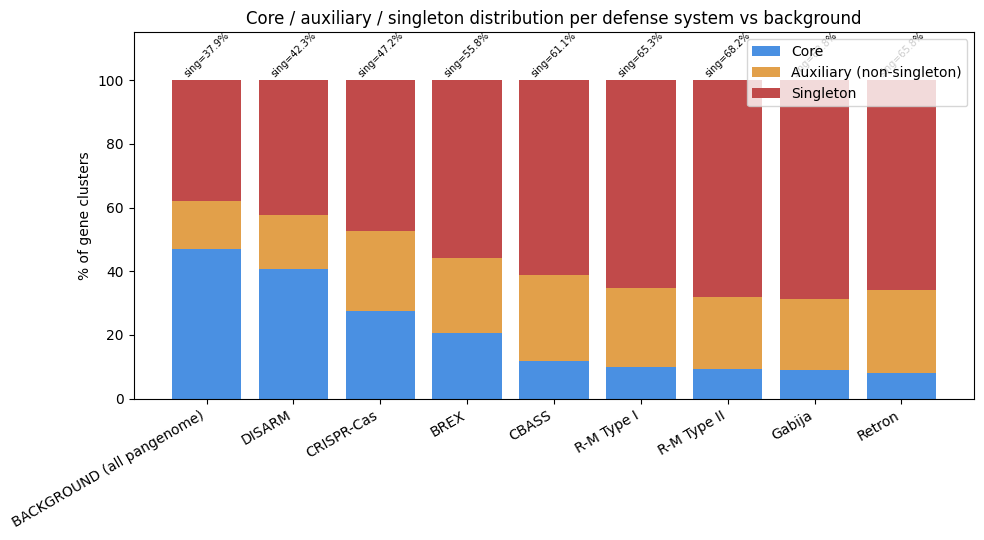

Saved: ../figures/core_vs_accessory_by_system.png


In [6]:
plot_rows = []
plot_rows.append({"system": "BACKGROUND (all pangenome)",
                  "core_frac": bg_core / bg_total,
                  "aux_ns_frac": bg_aux_ns / bg_total,
                  "sing_frac": bg_sing / bg_total})
for sys in sys_df["system"]:
    d_row = chi_df[chi_df["system"] == sys].iloc[0]
    total = d_row["d_core"] + d_row["d_aux_ns"] + d_row["d_sing"]
    plot_rows.append({
        "system": sys,
        "core_frac": d_row["d_core"] / total,
        "aux_ns_frac": d_row["d_aux_ns"] / total,
        "sing_frac": d_row["d_sing"] / total,
    })
plot_df = pd.DataFrame(plot_rows)

fig, ax = plt.subplots(figsize=(10, 5.5))
labels = plot_df["system"].values
core = plot_df["core_frac"].values * 100
aux = plot_df["aux_ns_frac"].values * 100
sing = plot_df["sing_frac"].values * 100
x = np.arange(len(labels))
ax.bar(x, core, color="#4a90e2", label="Core")
ax.bar(x, aux, bottom=core, color="#e2a04a", label="Auxiliary (non-singleton)")
ax.bar(x, sing, bottom=core + aux, color="#c14a4a", label="Singleton")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("% of gene clusters")
ax.set_title("Core / auxiliary / singleton distribution per defense system vs background")
ax.legend(loc="upper right")
# Annotate singleton fraction on top of each bar
for i, (c, a, s) in enumerate(zip(core, aux, sing)):
    ax.text(i, 101, f"sing={s:.1f}%", ha="center", fontsize=7, rotation=45)
ax.set_ylim(0, 115)
plt.tight_layout()
out = os.path.join(FIG_DIR, "core_vs_accessory_by_system.png")
plt.savefig(out, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

## 6. Save

In [7]:
out_tsv = os.path.join(DATA_DIR, "accessory_enrichment.tsv")
chi_df.to_csv(out_tsv, sep="\t", index=False)
print(f"Wrote: {out_tsv}")
sys_df.to_csv(os.path.join(DATA_DIR, "system_core_aux_summary.tsv"), sep="\t", index=False)

Wrote: ../data/accessory_enrichment.tsv


## Summary

For each defense system, compares the core/auxiliary/singleton fraction
distribution against the pangenome-wide background via 2×3 χ². A defense
system with elevated `pct_singleton` (relative to background ~15-25%) is a
candidate for high mobility.

**Next**: hand off to `/synthesize` — compile the three-hypothesis story into `REPORT.md`.